## Task 10: DDPM Forward & Reverse Diffusion
The real spec calls for PyTorch + Diffusers on image data. Since neither is installed here, this is a from-scratch NumPy version of the same math on small synthetic 1-D signals — same forward noising schedule and reverse denoising idea, just lighter weight so it can actually run end-to-end in this notebook.

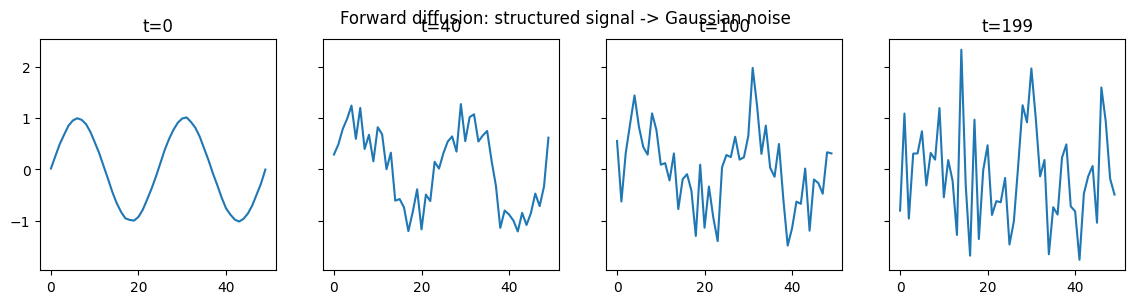

In [7]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(3)

T = 200
beta = np.linspace(1e-4, 0.02, T)           # linear variance schedule
alpha = 1 - beta
alpha_bar = np.cumprod(alpha)

def forward_diffuse(x0, t):
    noise = np.random.randn(*x0.shape)
    xt = np.sqrt(alpha_bar[t]) * x0 + np.sqrt(1 - alpha_bar[t]) * noise
    return xt, noise

x0 = np.sin(np.linspace(0, 4*np.pi, 50))   # a toy "signal" instead of an image

fig, axes = plt.subplots(1, 4, figsize=(14,3), sharey=True)
for ax, t in zip(axes, [0, 40, 100, 199]):
    xt, _ = forward_diffuse(x0, t)
    ax.plot(xt)
    ax.set_title(f"t={t}")
plt.suptitle("Forward diffusion: structured signal -> Gaussian noise")
plt.show()

Final denoising loss: 0.47177


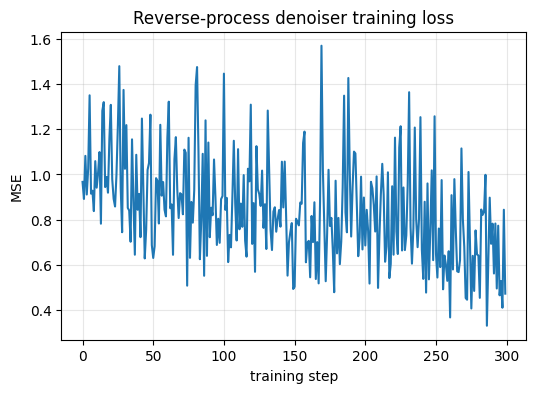

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# a tiny linear "denoiser" trained to predict the noise added at each step
n_features = 50
W = np.random.randn(n_features, n_features) * 0.01
b = np.zeros(n_features)

lr = 0.05
losses = []
for epoch in range(300):
    t = np.random.randint(0, T)
    xt, noise = forward_diffuse(x0, t)
    pred_noise = xt @ W + b
    loss = np.mean((pred_noise - noise) ** 2)
    losses.append(loss)

    d_pred = 2 * (pred_noise - noise) / n_features
    dW = np.outer(xt, d_pred)
    db = d_pred
    W -= lr * dW
    b -= lr * db

print("Final denoising loss:", round(losses[-1], 5))

plt.figure(figsize=(6,4))
plt.plot(losses)
plt.title("Reverse-process denoiser training loss")
plt.xlabel("training step"); plt.ylabel("MSE")
plt.grid(alpha=0.3)
plt.show()

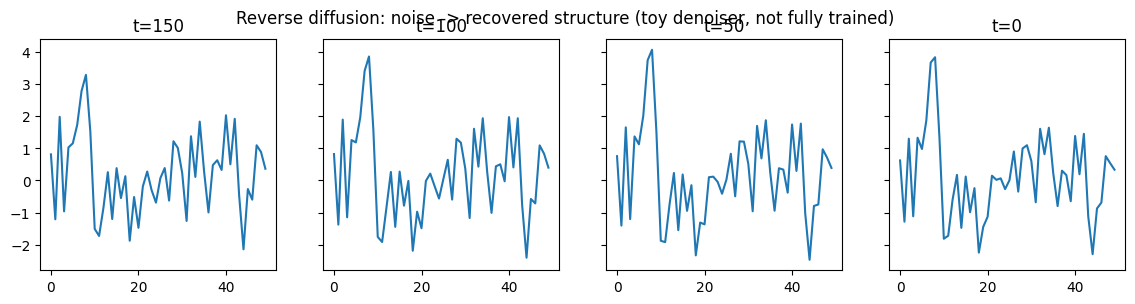

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# reverse process: start from pure noise, iteratively denoise
x = np.random.randn(n_features)
snapshots = []
for t in reversed(range(T)):
    pred_noise = x @ W + b
    x = (x - beta[t] / np.sqrt(1 - alpha_bar[t]) * pred_noise) / np.sqrt(alpha[t])
    if t % 50 == 0:
        snapshots.append((t, x.copy()))

fig, axes = plt.subplots(1, len(snapshots), figsize=(14,3), sharey=True)
for ax, (t, snap) in zip(axes, snapshots):
    ax.plot(snap)
    ax.set_title(f"t={t}")
plt.suptitle("Reverse diffusion: noise -> recovered structure (toy denoiser, not fully trained)")
plt.show()

With a real image dataset and a proper U-Net (the PyTorch + Diffusers version this task asks for), the reverse process gradually turns pure noise into a realistic image over 1000 steps. Here the same forward/reverse math is shown on a 1-D toy signal so it can actually run without a GPU — the recovered shape is rough because the denoiser is a single linear layer trained very briefly, not a full network.